In [11]:
!pip install -q kaggle

In [12]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dipanshushende","key":"f267971378417569963ff5e82e421ccb"}'}

In [13]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

In [14]:
!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
leapgestrecog.zip: Skipping, found more recently modified local copy (use --force to force download)


In [15]:
!unzip -q leapgestrecog.zip -d /content/

In [16]:
import os

print(os.listdir("/content"))

['.config', 'kaggle.json', 'dataset', 'leapgestrecog', 'leapgestrecog.zip', 'leapGestRecog', 'sample_data']


In [17]:
!find /content/leapGestRecog -maxdepth 2 -type d

/content/leapGestRecog
/content/leapGestRecog/04
/content/leapGestRecog/04/08_palm_moved
/content/leapGestRecog/04/04_fist_moved
/content/leapGestRecog/04/03_fist
/content/leapGestRecog/04/02_l
/content/leapGestRecog/04/06_index
/content/leapGestRecog/04/07_ok
/content/leapGestRecog/04/05_thumb
/content/leapGestRecog/04/01_palm
/content/leapGestRecog/04/10_down
/content/leapGestRecog/04/09_c
/content/leapGestRecog/08
/content/leapGestRecog/08/08_palm_moved
/content/leapGestRecog/08/04_fist_moved
/content/leapGestRecog/08/03_fist
/content/leapGestRecog/08/02_l
/content/leapGestRecog/08/06_index
/content/leapGestRecog/08/07_ok
/content/leapGestRecog/08/05_thumb
/content/leapGestRecog/08/01_palm
/content/leapGestRecog/08/10_down
/content/leapGestRecog/08/09_c
/content/leapGestRecog/01
/content/leapGestRecog/01/08_palm_moved
/content/leapGestRecog/01/04_fist_moved
/content/leapGestRecog/01/03_fist
/content/leapGestRecog/01/02_l
/content/leapGestRecog/01/06_index
/content/leapGestRecog/01/0

In [18]:
!pip install -q tensorflow

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [20]:
import os
import cv2
import numpy as np

dataset_path = "/content/leapGestRecog"

images = []
labels = []

IMG_SIZE = 64

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    for gesture in os.listdir(person_path):

        gesture_path = os.path.join(person_path, gesture)

        if not os.path.isdir(gesture_path):
            continue

        # Labels: 01-10 -> 0-9
        label = int(gesture.split('_')[0]) - 1

        for img_name in os.listdir(gesture_path):

            img_path = os.path.join(gesture_path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (64, 64))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            images.append(img)
            labels.append(label)

print("Total Images Loaded:", len(images))

Total Images Loaded: 20000


In [21]:
X = np.array(images)
y = np.array(labels)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Images Shape: (20000, 64, 64, 3)
Labels Shape: (20000,)


In [22]:
print("Unique Labels:", np.unique(y))

Unique Labels: [0 1 2 3 4 5 6 7 8 9]


In [23]:
X = X / 255.0

In [24]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=10)

print(y.shape)

(20000, 10)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16000, 64, 64, 3)
(4000, 64, 64, 3)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16000, 64, 64, 3)
(4000, 64, 64, 3)


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 138ms/step - accuracy: 0.8811 - loss: 0.3561 - val_accuracy: 0.9973 - val_loss: 0.0098
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.9872 - loss: 0.0414 - val_accuracy: 0.9987 - val_loss: 0.0045
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 145ms/step - accuracy: 0.9921 - loss: 0.0234 - val_accuracy: 0.9987 - val_loss: 0.0048
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 136ms/step - accuracy: 0.9939 - loss: 0.0176 - val_accuracy: 0.9992 - val_loss: 0.0029
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 137ms/step - accuracy: 0.9952 - loss: 0.0154 - val_accuracy: 0.9998 - val_loss: 0.0014
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 140ms/step - accuracy: 0.9958 - loss: 0.0126 - val_accuracy: 0.9992 - val_loss: 0.0025
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 137ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9995 - val_loss: 9.2753e-04
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 138ms/step - accuracy: 0.9967 - los

In [29]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9995 - loss: 9.1754e-04
Test Loss: 0.0009175437153317034
Test Accuracy: 0.9994999766349792


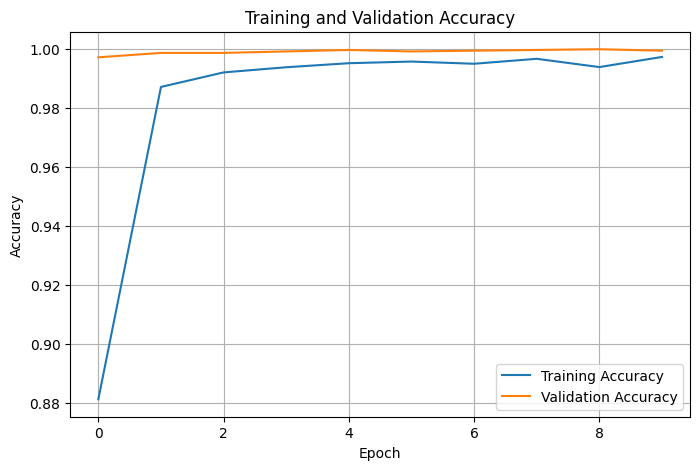

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


In [31]:
import numpy as np

predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step


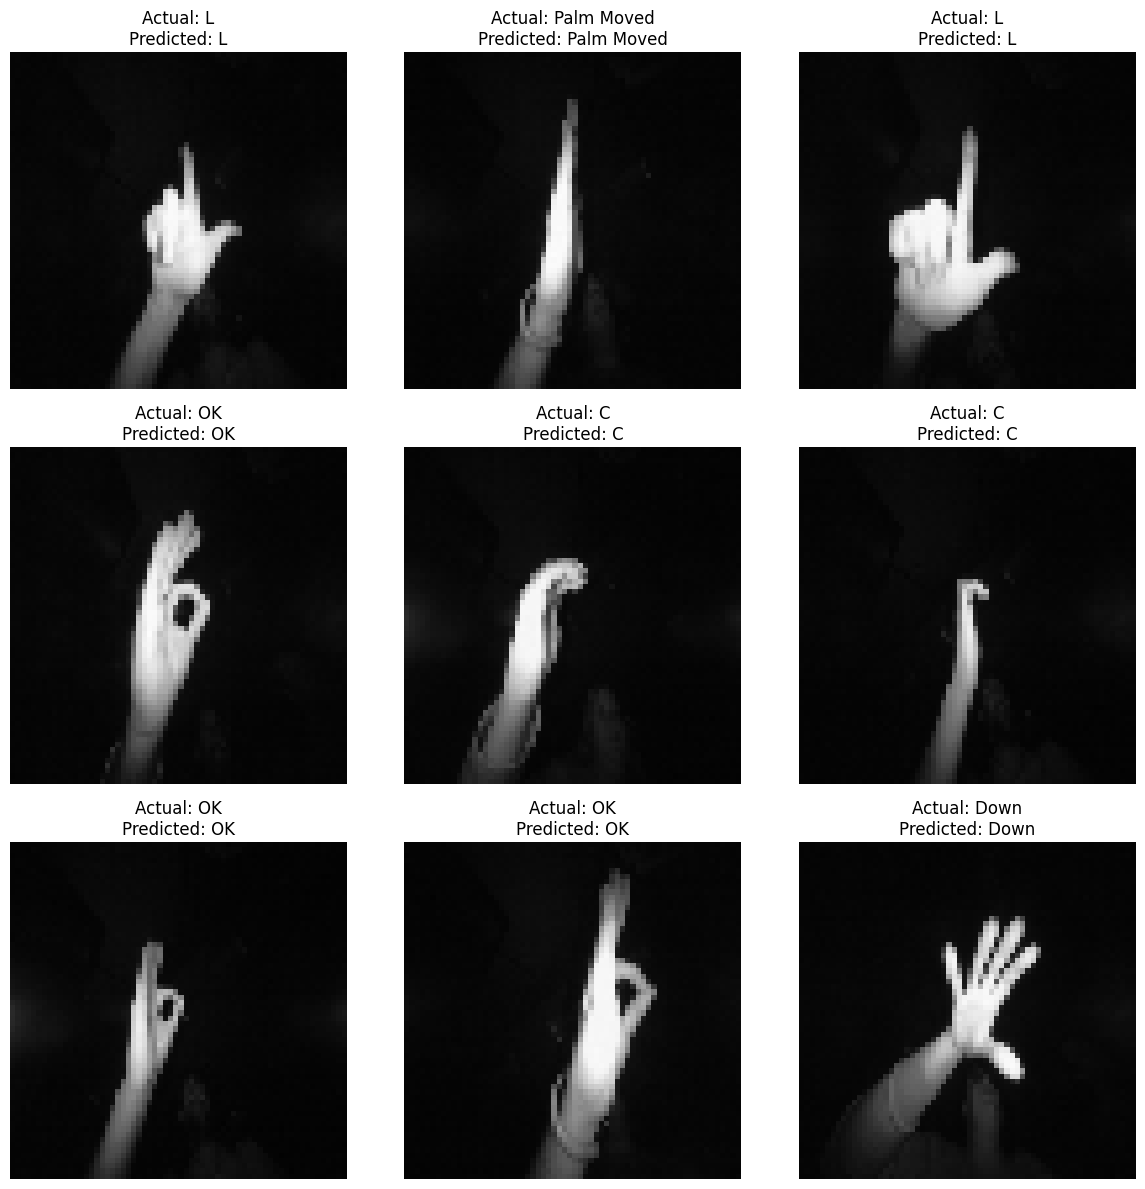

In [32]:
gesture_names = [
    "Palm",
    "L",
    "Fist",
    "Fist Moved",
    "Thumb",
    "Index",
    "OK",
    "Palm Moved",
    "C",
    "Down"
]

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i])
    plt.title(f"Actual: {gesture_names[true_labels[i]]}\nPredicted: {gesture_names[predicted_labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       409
           1       1.00      1.00      1.00       418
           2       1.00      1.00      1.00       404
           3       1.00      1.00      1.00       404
           4       1.00      1.00      1.00       403
           5       1.00      1.00      1.00       377
           6       1.00      1.00      1.00       392
           7       1.00      1.00      1.00       417
           8       1.00      1.00      1.00       366
           9       1.00      1.00      1.00       410

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [34]:
model.save("hand_gesture_recognition_model.h5")

print("Model saved successfully!")

Model saved successfully!
